In [ ]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')
PROJECT_ROOT = Path('/content/drive/MyDrive/TA_SER')


FEATURES_ROOT    = PROJECT_ROOT / 'data' / 'processed' / 'features_v4'
LABEL_ENCODER_FP = PROJECT_ROOT / 'data' / 'processed' / 'label_encoder.json'
MODEL_DIR        = PROJECT_ROOT / 'saved_models' / 'v4'
REPORTS_DIR      = PROJECT_ROOT / 'reports'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE       = 32
MAX_EPOCHS       = 100
LEARNING_RATE    = 0.001
LABEL_SMOOTHING  = 0.1
L2_REG           = 0.0002
DROPOUT_CONV     = 0.25
DROPOUT_INTEGRATE= 0.35
DROPOUT_DENSE    = 0.5
PATIENCE_ES      = 15
PATIENCE_LR      = 7
LR_FACTOR        = 0.5
MIN_LR           = 1e-6

MODEL_NAME       = 'model_C_v3'
BRANCH_FILTERS   = 96
BRANCH_KERNELS   = [3, 5, 7]
BRANCH_DILATIONS = [1, 2, 3]
PADDING_MODE     = 'same'
INTEGRATE_FILTERS= 128
INTEGRATE_KERNEL = 3
DENSE_UNITS      = 128

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_SHAPE = (188, 40)
NUM_CLASSES = 4

print(f'TF version: {tf.__version__}')
print(f'Model name: {MODEL_NAME}')
print(f'Branch filters : {BRANCH_FILTERS} (TRIAL)')
print(f'Branch dilations: {BRANCH_DILATIONS} (TRIAL)')
print(f'Padding: {PADDING_MODE} (TRIAL)')


Mounted at /content/drive
TF version: 2.19.0
Model name: model_C_v3
Branch filters : 96 (TRIAL)
Branch dilations: [1, 2, 3] (TRIAL)
Padding: same (TRIAL)


In [ ]:
with open(LABEL_ENCODER_FP, 'r') as f:
    label_enc = json.load(f)

LABEL_TO_INT  = label_enc['label_to_int']
INT_TO_LABEL  = {int(k): v for k, v in label_enc['int_to_label'].items()}
TARGET_LABELS = label_enc['target_labels']

print(f'Target labels: {TARGET_LABELS}')


Target labels: ['angry', 'happy', 'neutral', 'sad']


In [ ]:
X_train = np.load(FEATURES_ROOT / 'train' / 'X_train.npy')
y_train = np.load(FEATURES_ROOT / 'train' / 'y_train.npy')
sources_train = np.load(FEATURES_ROOT / 'train' / 'sources_train.npy', allow_pickle=True)
y_train_oh = to_categorical(y_train, num_classes=NUM_CLASSES)

print(f'X_train: {X_train.shape}')

val_per_source = {}
for src in ['ravdess', 'emodb', 'tess', 'savee']:
    X_v = np.load(FEATURES_ROOT / 'val' / f'X_val_{src}.npy')
    y_v = np.load(FEATURES_ROOT / 'val' / f'y_val_{src}.npy')
    val_per_source[src] = {
        'X': X_v,
        'y': y_v,
        'y_oh': to_categorical(y_v, num_classes=NUM_CLASSES)
    }
    print(f'  val_{src}: {X_v.shape}')

X_val_combined = np.load(FEATURES_ROOT / 'val' / 'X_val_combined.npy')
y_val_combined = np.load(FEATURES_ROOT / 'val' / 'y_val_combined.npy')
y_val_combined_oh = to_categorical(y_val_combined, num_classes=NUM_CLASSES)
print(f'X_val_combined: {X_val_combined.shape}')


X_train: (9312, 188, 40)
  val_ravdess: (67, 188, 40)
  val_emodb: (34, 188, 40)
  val_tess: (160, 188, 40)
  val_savee: (30, 188, 40)
X_val_combined: (291, 188, 40)


In [ ]:
def build_branch(x, filters, kernel_size, dilation_rate, name_prefix):

    x = layers.Conv1D(
        filters, kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding=PADDING_MODE,
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name=f'{name_prefix}_conv'
    )(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn')(x)
    x = layers.Activation('relu', name=f'{name_prefix}_relu')(x)
    x = layers.Dropout(DROPOUT_CONV, name=f'{name_prefix}_drop')(x)
    x = layers.MaxPooling1D(pool_size=2, name=f'{name_prefix}_pool')(x)
    return x


def build_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape, name='input')

    branches = []
    for i, (k, d) in enumerate(zip(BRANCH_KERNELS, BRANCH_DILATIONS)):
        branch = build_branch(
            inputs,
            filters=BRANCH_FILTERS,
            kernel_size=k,
            dilation_rate=d,
            name_prefix=f'branch{i+1}_k{k}_d{d}'
        )
        branches.append(branch)

    x = layers.Concatenate(axis=-1, name='concat')(branches)

    x = layers.Conv1D(
        INTEGRATE_FILTERS, kernel_size=INTEGRATE_KERNEL, padding='same',
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name='integrate_conv'
    )(x)
    x = layers.BatchNormalization(name='integrate_bn')(x)
    x = layers.Activation('relu', name='integrate_relu')(x)
    x = layers.Dropout(DROPOUT_INTEGRATE, name='integrate_drop')(x)

    x = layers.GlobalAveragePooling1D(name='gap')(x)
    x = layers.Dense(
        DENSE_UNITS, activation='relu',
        kernel_regularizer=keras.regularizers.l2(L2_REG), name='dense1'
    )(x)
    x = layers.Dropout(DROPOUT_DENSE, name='drop_dense')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name=MODEL_NAME)


model = build_model()
model.summary()
total_params = model.count_params()
print(f'\n Total params: {total_params:,}')


Model: "model_C_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 188, 40)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_conv  │ (None, 188, 96)   │     11,616 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_conv  │ (None, 188, 96)   │     19,296 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d3_conv  │ (None, 188, 96)   │     26,976 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_bn    │ (None, 188, 96)   │        384 │ branch1_k3_d1_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_bn    │ (None, 188, 96)   │        384 │ branch2_k5_d2_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d3_bn    │ (None, 188, 96)   │        384 │ branch3_k7_d3_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_relu  │ (None, 188, 96)   │          0 │ branch1_k3_d1_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_relu  │ (None, 188, 96)   │          0 │ branch2_k5_d2_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d3_relu  │ (None, 188, 96)   │          0 │ branch3_k7_d3_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_drop  │ (None, 188, 96)   │          0 │ branch1_k3_d1_re… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_drop  │ (None, 188, 96)   │          0 │ branch2_k5_d2_re… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d3_drop  │ (None, 188, 96)   │          0 │ branch3_k7_d3_re… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_pool  │ (None, 94, 96)    │          0 │ branch1_k3_d1_dr… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_pool  │ (None, 94, 96)    │          0 │ branch2_k5_d2_dr… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d3_pool  │ (None, 94, 96)    │          0 │ branch3_k7_d3_dr… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 94, 288)   │          0 │ branch1_k3_d1_po… │
│ (Concatenate)       │                   │            │ branch2_k5_d2_po

 Total params: 187,300 (731.64 KB)

 Trainable params: 186,468 (728.39 KB)

 Non-trainable params: 832 (3.25 KB)


 Total params: 187,300


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)
print(' Model compiled')


 Model compiled


In [ ]:
class PerSourceValAccCallback(Callback):
    def __init__(self, val_per_source):
        super().__init__()
        self.val_per_source = val_per_source
        self.history_per_source = {src: [] for src in val_per_source.keys()}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        for src, data in self.val_per_source.items():
            y_pred = self.model.predict(data['X'], verbose=0)
            y_pred_class = np.argmax(y_pred, axis=1)
            acc = float(np.mean(y_pred_class == data['y']))
            self.history_per_source[src].append(acc)
            logs[f'val_acc_{src}'] = acc


per_source_callback = PerSourceValAccCallback(val_per_source)
print(' Callback initialized')


 Callback initialized


In [ ]:
checkpoint_path = MODEL_DIR / f'{MODEL_NAME}_best.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE_ES, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=PATIENCE_LR, factor=LR_FACTOR, min_lr=MIN_LR, verbose=1),
    ModelCheckpoint(filepath=str(checkpoint_path), monitor='val_loss', save_best_only=True, verbose=0),
    per_source_callback
]

print(f' Callbacks setup | checkpoint: {checkpoint_path.name}')


 Callbacks setup | checkpoint: model_C_v3_best.keras


In [ ]:
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val_combined, y_val_combined_oh),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

print(f'\n Training complete')
print(f'  Final epoch: {len(history.history["loss"])}')
print(f'  Best val_loss: {min(history.history["val_loss"]):.4f}')
print(f'  Best val_acc : {max(history.history["val_accuracy"]):.4f}')


Epoch 1/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.7630 - loss: 0.8989 - val_accuracy: 0.7904 - val_loss: 0.8139 - learning_rate: 0.0010 - val_acc_ravdess: 0.4328 - val_acc_emodb: 0.5882 - val_acc_tess: 0.9938 - val_acc_savee: 0.7333
Epoch 2/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8513 - loss: 0.7427 - val_accuracy: 0.8694 - val_loss: 0.6919 - learning_rate: 0.0010 - val_acc_ravdess: 0.6567 - val_acc_emodb: 0.7941 - val_acc_tess: 1.0000 - val_acc_savee: 0.7333
Epoch 3/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8806 - loss: 0.6880 - val_accuracy: 0.8763 - val_loss: 0.6807 - learning_rate: 0.0010 - val_acc_ravdess: 0.6567 - val_acc_emodb: 0.7941 - val_acc_tess: 1.0000 - val_acc_savee: 0.8000
Epoch 4/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9076 - loss: 0.6482 - val_accuracy: 0.8866 - val_loss: 0.6588 - learning_rate: 0.0010 - val_acc_ravdess: 0.7463 - val_acc_emodb: 0.7941 - val_acc_tess: 0.9875 - val_acc_savee: 0.766

In [ ]:
full_history = dict(history.history)
full_history['val_acc_per_source'] = per_source_callback.history_per_source

def sanitize(obj):
    if isinstance(obj, dict):
        return {k: sanitize(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

full_history_clean = sanitize(full_history)
full_history_clean['_metadata'] = {
    'model_name': MODEL_NAME,
    'is_trial': True,
    'input_shape': list(INPUT_SHAPE),
    'num_classes': NUM_CLASSES,
    'total_params': int(total_params),
    'config': {
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'label_smoothing': LABEL_SMOOTHING,
        'l2_reg': L2_REG,
        'dropout_conv': DROPOUT_CONV,
        'dropout_integrate': DROPOUT_INTEGRATE,
        'dropout_dense': DROPOUT_DENSE,
        'branch_filters': BRANCH_FILTERS,
        'branch_kernels': BRANCH_KERNELS,
        'branch_dilations': BRANCH_DILATIONS,
        'padding_mode': PADDING_MODE,
        'integrate_filters': INTEGRATE_FILTERS,
    },
    'epochs_trained': len(history.history['loss']),
    'best_val_loss': float(min(history.history['val_loss'])),
    'best_val_acc': float(max(history.history['val_accuracy'])),
}

variant_suffix = MODEL_NAME.replace('model_', '')
history_path = MODEL_DIR / f'history_{variant_suffix}.json'
with open(history_path, 'w') as f:
    json.dump(full_history_clean, f, indent=2)

print(f' History saved: {history_path}')


 History saved: /content/drive/MyDrive/TA_SER/saved_models/v4/history_C_v3.json


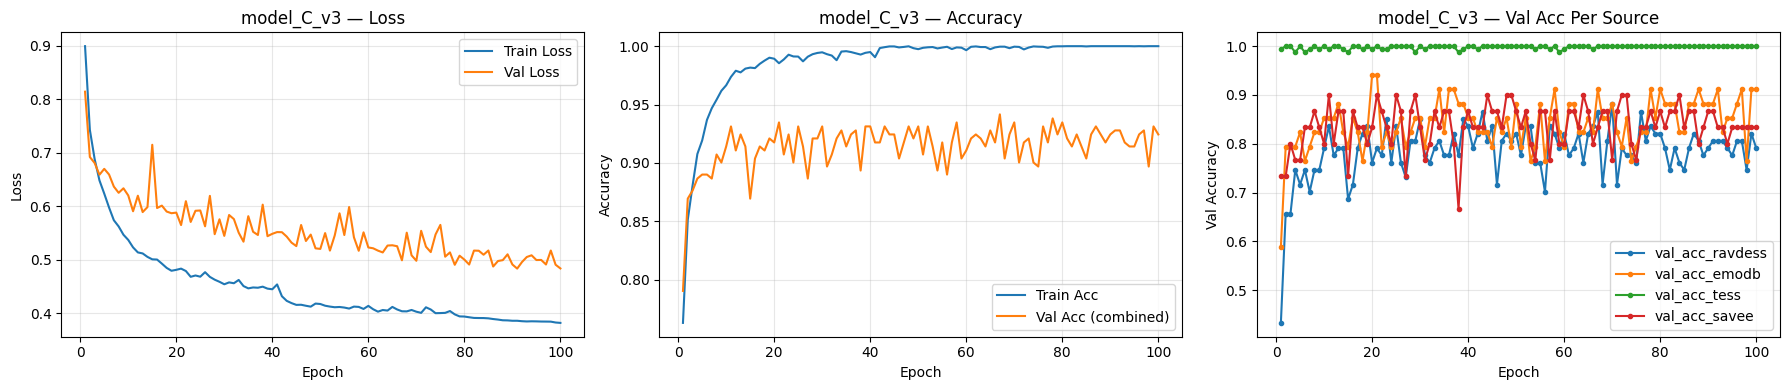

 Plot saved: /content/drive/MyDrive/TA_SER/reports/training_curves_C_v3.png


In [ ]:
epochs = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history.history['loss'], label='Train Loss')
axes[0].plot(epochs, history.history['val_loss'], label='Val Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history.history['accuracy'], label='Train Acc')
axes[1].plot(epochs, history.history['val_accuracy'], label='Val Acc (combined)')
axes[1].set_title(f'{MODEL_NAME} — Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

for src, acc_list in per_source_callback.history_per_source.items():
    axes[2].plot(range(1, len(acc_list)+1), acc_list, label=f'val_acc_{src}', marker='.')
axes[2].set_title(f'{MODEL_NAME} — Val Acc Per Source')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Val Accuracy')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
curves_path = REPORTS_DIR / f'training_curves_{variant_suffix}.png'
plt.savefig(curves_path, dpi=100, bbox_inches='tight')
plt.show()

print(f' Plot saved: {curves_path}')


In [ ]:
print('=' * 70)
print(f'{MODEL_NAME} — Training Summary')
print('=' * 70)
print(f'Total params          : {total_params:,}')
print(f'Epochs trained        : {len(history.history["loss"])}')
print(f'Best val_loss         : {min(history.history["val_loss"]):.4f}')
print(f'Best val_acc (combined): {max(history.history["val_accuracy"]):.4f}')
print()
print('Final val_acc per source:')
for src, acc_list in per_source_callback.history_per_source.items():
    print(f'  {src:8s}: last={acc_list[-1]:.3f}  best={max(acc_list):.3f}')

print()
print('=' * 70)
print('FULL ABLATION COMPARISON')
print('=' * 70)
try:
    comparison = {}
    for m_name in ['A', 'B', 'C', 'C_v2', 'C_v3']:
        h_path = MODEL_DIR / f'history_{m_name}.json'
        if h_path.exists():
            with open(h_path, 'r') as f:
                h = json.load(f)
            # Get final per-source val acc
            per_src = h.get('val_acc_per_source', {})
            best_per_src = {s: max(accs) if accs else 0 for s, accs in per_src.items()}
            comparison[m_name] = {
                'params': h['_metadata']['total_params'],
                'best_val_loss': h['_metadata']['best_val_loss'],
                'best_val_acc': h['_metadata']['best_val_acc'],
                'per_src': best_per_src
            }

    if comparison:

        print(f"{'Model':8s} {'Params':>10s} {'ValLoss':>9s} {'ValAcc':>8s} {'RAVD':>7s} {'EMODB':>7s} {'TESS':>7s} {'SAVEE':>7s}")
        print('-' * 70)
        for m, d in comparison.items():
            per_src = d['per_src']
            print(f"{'Model ' + m:8s} {d['params']:>10,} {d['best_val_loss']:>9.4f} {d['best_val_acc']:>8.4f}"
                  f"{per_src.get('ravdess', 0):>7.3f} {per_src.get('emodb', 0):>7.3f}"
                  f"{per_src.get('tess', 0):>7.3f} {per_src.get('savee', 0):>7.3f}")

        print()
        best_combined = max(comparison.items(), key=lambda x: x[1]['best_val_acc'])
        print(f'Best val_acc (combined): Model {best_combined[0]} ({best_combined[1]["best_val_acc"]:.4f})')

        if 'A' in comparison:
            baseline_acc = comparison['A']['best_val_acc']
            trial_acc = max(history.history['val_accuracy'])
            delta = (trial_acc - baseline_acc) * 100
            status = ' BEAT' if delta > 0 else ' LOSE' if delta < -0.5 else '≈ TIE'
            print(f'{MODEL_NAME} vs Model A: {status} (Δ = {delta:+.2f}%)')
    else:
        print('Ga ada history untuk compare')
except Exception as e:
    print(f'Comparison skipped: {e}')

print()
print(f'Checkpoint: {checkpoint_path}')
print(f'History   : {history_path}')
print(f'Plot      : {curves_path}')


model_C_v3 — Training Summary
Total params          : 187,300
Epochs trained        : 100
Best val_loss         : 0.4835
Best val_acc (combined): 0.9416

Final val_acc per source:
  ravdess : last=0.791  best=0.881
  emodb   : last=0.912  best=0.941
  tess    : last=1.000  best=1.000
  savee   : last=0.833  best=0.900

FULL ABLATION COMPARISON
Model        Params   ValLoss   ValAcc    RAVD   EMODB    TESS   SAVEE
----------------------------------------------------------------------
Model A     253,252    0.4837   0.9450  0.881   0.941  1.000   0.967
Model B     130,756    0.5214   0.9347  0.851   0.912  1.000   0.933
Model C     130,756    0.5167   0.9313  0.851   0.853  1.000   0.933
Model C_v2    130,756    0.4854   0.9519  0.881   0.941  1.000   0.933
Model C_v3    187,300    0.4835   0.9416  0.881   0.941  1.000   0.900

Best val_acc (combined): Model C_v2 (0.9519)
model_C_v3 vs Model A: ≈ TIE (Δ = -0.34%)

Checkpoint: /content/drive/MyDrive/TA_SER/saved_models/v4/model_C_v3_best.